# 06 · Tarea 3 — AutoML con Keras Tuner

**Objetivo.** Buscar automáticamente la **topología** de la red de impago con **Keras Tuner** (estrategia **Hyperband** o *RandomSearch*, **D-3.1**) sobre un espacio de hiperparámetros que incluye **nº de capas**, **unidades por capa**, **dropout + su `rate` (sí o sí)**, **learning rate** (escala log) y **función de activación** (**D-3.2**). El `objective` del tuner es **`val_auc`** a maximizar (**D-3.4**), tratando el **fairness como eje externo** (`λ_fair`) y no como objetivo del escalar.

Como el tuner optimiza un único escalar, la frontera de Pareto **no sale gratis**: se construye con un **bucle externo sobre `λ`** (**D-3.3**) que, para cada valor, registra el par **(AUC, group gap)** → eso produce el entregable **E2** (Pareto Precisión vs Dependencia FAIR).

**Acople con la Tarea 2 (FAIR loss).** El `build_model(hp)` integra la **capa custom** del notebook 04 (ratio + saturación `x^p`) y la **FAIR loss** `BCE + λ·D` del notebook 05. La dependencia `D` se toma directamente de **`src/fair_loss.py`** (Tarea 2), donde están implementadas y verificadas las **tres** medidas — **corr²**, **HSIC** y **MMD** (`DEPENDENCE_MEASURES`). Este notebook las **compara**: usa Keras Tuner para fijar una **topología backbone** y luego barre `λ` con las 3 medidas sobre esa misma red, para ver cuál traza la mejor frontera precisión↔justicia (cerrando **D-2.1**). La **mejor topología con dropout** que aquí se fija la **hereda el notebook 07** para **MC-Dropout** (cruce **D-3.2 ↔ D-4.1**). Aguas arriba depende de 03 (baseline de precisión), 04 (capa) y 05 (loss).

## Decisiones a tomar antes de empezar

> Fichas de `docs/DECISIONES.md` para esta tarea, con su **estado real**.

| Decisión | Opciones | Estado |
|---|---|---|
| **D-3.1** · Estrategia de búsqueda | RandomSearch / Hyperband / BayesianOptimization | Confirmada — empate técnico (Δval_auc<0,001); se usa **RandomSearch** (igual de válido y más barato) |
| **D-3.2** · Hiperparámetros del espacio | nº capas / unidades / **dropout (+rate)** / lr (log) / activación | Confirmada |
| **D-3.3** · Extraer pares (precisión, dependencia) | callback / **bucle externo sobre λ** / tuner multiobjetivo | Confirmada |
| **D-3.4** · Métrica objetivo del tuner | val_loss / **val_auc** / custom combinada | Confirmada |
| **D-2.1** · Medida de dependencia `D(p,s)` | **corr² / HSIC / MMD** (de `src/fair_loss.py`) | Comparadas las 3 aquí |

> **Cruce dropout 3↔4 (D-3.2 ↔ D-4.1).** El **dropout entra obligatoriamente** en el espacio de búsqueda **porque** el notebook 07 reutiliza esta misma topología para **MC-Dropout** (T pasadas con `training=True` en inferencia → `Var[p]`). **07 hereda la red con dropout** que aquí se fija.

> **Fairness como eje externo.** El tuner **NO optimiza fairness**: su `objective` es `val_auc` (D-3.4). El **group gap** (D-2.3) se recoge en el **bucle externo sobre `λ`** (D-3.3). Dos cifras de "gap" conviven y no hay que confundirlas: la **línea base de los datos** del EDA es **+3,14 pp** (gap de las etiquetas reales M−F), mientras que el **group gap del modelo base sin FAIR** (en predicciones) es mayor, **~5,6 pp en test** — el modelo *amplifica* la desigualdad, y eso es lo que la FAIR loss corrige. La **medida de dependencia** es también eje externo: se comparan las **tres** de la Tarea 2 sobre el backbone fijo para cerrar **D-2.1**.

## Setup e imports

> **Aviso de instalación.** Este notebook usa **`keras-tuner`**, que **NO está
> instalado por defecto** en el entorno (sí lo están `keras` 3.x y `tensorflow`).
> Antes de lanzar la búsqueda del tuner hay que instalarlo:
>
> ```bash
> pip install keras-tuner --upgrade
> ```
>
> El import va **guardado con `try/except`** para que el esqueleto no se rompa
> aunque la librería falte; las celdas de búsqueda (`# TODO`) solo se ejecutan
> tras instalarla.

In [1]:
# === Setup comun (notebooks de modelado 03-07) ===
import os
os.environ["KERAS_BACKEND"] = "tensorflow"   # backend unico para todo el grupo

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
RNG = 42
np.random.seed(RNG)
import random; random.seed(RNG)
try:
    import keras
    keras.utils.set_random_seed(RNG)
except Exception:
    pass

# Estilo heredado del EDA / preprocesado
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
COLOR_PAGA   = "#2c7fb8"   # TARGET=0  (paga)
COLOR_IMPAGA = "#d7301f"   # TARGET=1  (impaga)
COLOR_ACENTO = "#41ab5d"   # neutro

# Rutas estandar
PROC_DIR = Path("../data/processed")
FIG_DIR  = Path("../results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR  = Path("../results/tables");  TAB_DIR.mkdir(parents=True, exist_ok=True)

# --- Especifico de la Tarea 3 (Keras Tuner) ---
import sys; sys.path.append("..")   # para importar src/ (p.ej. src/tuning.py)
import keras

# Import guardado: keras-tuner NO esta instalado por defecto (ver nota previa)
try:
    import keras_tuner as kt
    _HAS_KT = True
except ImportError:
    _HAS_KT = False
    print("keras-tuner no instalado -> pip install keras-tuner --upgrade")

In [2]:
import json
from pathlib import Path
import pandas as pd

# --- Rutas y metadatos (fuente de verdad: metadata.json del preprocesado) ---
PROC_DIR   = Path("../data/processed")                       # relativo a notebooks/
META       = json.loads((PROC_DIR / "metadata.json").read_text(encoding="utf-8"))
FEATURES_X = META["columns"]["features_X"]   # 13 features, en orden
SENSIBLE   = META["columns"]["sensible"]     # "CODE_GENDER"  (s)
TARGET     = META["columns"]["target"]       # "TARGET"       (y)

# La capa custom (NB04) usa indices FIJOS income_idx=0, annuity_idx=2 sobre X.
# Verificamos que el orden de FEATURES_X los respeta (si cambia, la capa operaria
# sobre columnas equivocadas SILENCIOSAMENTE) -> assert defensivo.
assert FEATURES_X[0] == "AMT_INCOME_TOTAL", f"income_idx=0 roto: {FEATURES_X[0]}"
assert FEATURES_X[2] == "AMT_ANNUITY",      f"annuity_idx=2 roto: {FEATURES_X[2]}"

def cargar_split(nombre):
    """Devuelve (X, y, s) para 'train' | 'val' | 'test'.
    X = DataFrame solo con las 13 features (SIN genero).
    y = Series TARGET (1=impaga, 0=paga).  s = Series CODE_GENDER (M=1/F=0).
    """
    df = pd.read_parquet(PROC_DIR / f"{nombre}.parquet")
    X = df[FEATURES_X]          # input del modelo: el genero NUNCA entra aqui
    y = df[TARGET]
    s = df[SENSIBLE]
    assert SENSIBLE not in X.columns, "FUGA: el genero esta dentro de X"
    return X, y, s

# Materializar los tres cortes
X_train, y_train, s_train = cargar_split("train")
X_val,   y_val,   s_val   = cargar_split("val")
X_test,  y_test,  s_test  = cargar_split("test")

# Nota: convertir a tensores con X_*.to_numpy(dtype="float32") (idem y_*, s_*) en el
# punto de uso; s = CODE_GENDER NUNCA entra en X (solo FAIR loss + auditoria de equidad).

# Resumen de control
print(f"{'split':<7}{'X (filas, cols)':>20}{'y':>12}{'s':>12}{'tasa_impago':>14}")
for n, (X, y, s) in {"train": (X_train, y_train, s_train),
                     "val":   (X_val,   y_val,   s_val),
                     "test":  (X_test,  y_test,  s_test)}.items():
    print(f"{n:<7}{str(tuple(X.shape)):>20}{str(tuple(y.shape)):>12}"
          f"{str(tuple(s.shape)):>12}{y.mean():>14.4%}")

split       X (filas, cols)           y           s   tasa_impago
train          (215254, 13)   (215254,)   (215254,)       8.0728%
val             (46126, 13)    (46126,)    (46126,)       8.0735%
test            (46127, 13)    (46127,)    (46127,)       8.0734%


In [3]:
# === Helpers de ploteo Pareto (E2) — estilo unico para todas las figuras 06 ===
# Centraliza la linea base EDA, las flechas semanticas y el anti-solapamiento de
# etiquetas lambda, para que las figuras hablen el mismo idioma visual.
GAP_BASE_EDA = 3.14   # group gap REAL M-F del EDA (pp) — la desigualdad de los datos a batir
NOMBRE_MEDIDA = {"corr2": "corr²", "mmd": "MMD²", "hsic": "HSIC"}

def add_baseline_eda(ax, x=GAP_BASE_EDA):
    """Linea vertical = desigualdad REAL de los datos (referencia a batir)."""
    ax.axvline(x, color="#737373", ls=":", lw=1.6, zorder=1)
    ax.annotate(f"línea base EDA\n|gap| real = +{x:.2f} pp",
                xy=(x, ax.get_ylim()[0]), xytext=(4, 6), textcoords="offset points",
                va="bottom", ha="left", fontsize=8, color="#525252", style="italic")

def add_flechas_objetivo(ax):
    """Flechas semanticas: hacia donde es 'mas justo' (X-) y 'mas preciso' (Y+)."""
    ax.annotate("", xy=(0.02, -0.12), xytext=(0.30, -0.12), xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color=COLOR_ACENTO, lw=2))
    ax.text(0.02, -0.17, "más justo", transform=ax.transAxes,
            fontsize=9, color=COLOR_ACENTO, fontweight="bold", ha="left")

def label_lambdas_sin_solape(ax, xs, ys, labels, color="black", dy=8):
    """Etiquetas lambda alternando arriba/abajo para que no se pisen."""
    orden = np.argsort(xs)
    for k, i in enumerate(orden):
        signo = 1 if k % 2 == 0 else -1
        ax.annotate(labels[i], (xs[i], ys[i]), textcoords="offset points",
                    xytext=(6, signo * dy), fontsize=8.5, color=color,
                    va="bottom" if signo > 0 else "top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.65))

print("Helpers de ploteo cargados: add_baseline_eda, add_flechas_objetivo, label_lambdas_sin_solape")

Helpers de ploteo cargados: add_baseline_eda, add_flechas_objetivo, label_lambdas_sin_solape


## Espacio de búsqueda y `build_model(hp)`

Aquí se definirá la función `build_model(hp)` (en `src/tuning.py`) que declara el **espacio de búsqueda** con la API de Keras Tuner (D-3.2): nº de capas, unidades, dropout + `rate`, learning rate (log), activación y `λ_fair`, integrando la **capa custom** (04) al principio y compilando con la **FAIR loss** `BCE + λ·D` (05) y `metrics=[AUC]`.

In [4]:
# === Espacio de busqueda y build_model(hp) (D-3.2) ===
import importlib
import src.tuning as tuning
importlib.reload(tuning)

CW = tuning.class_weights_balanced(y_train)            # balance de clases (D-MB.3)
print(f"class_weight balanced (train): w0={CW[0]:.3f}  w1={CW[1]:.3f}")

# Acople con la Tarea 2: las 3 medidas vienen de src/fair_loss.py (Tarea 2).
print("\nDependencia FAIR (src/fair_loss.py, Tarea 2):")
for m in ["corr2", "hsic", "mmd"]:
    print(f"  measure='{m:5}' -> {tuning.fair_loss_source(m)}")
assert tuning.fair_loss_source("mmd").startswith("src.fair_loss"), \
    "src/fair_loss.py no disponible: se usaria el fallback corr2"

N_FEATURES = X_train.shape[1]                          # 13 features (SIN genero)
data = (X_train, y_train, s_train, X_val, y_val, s_val)

print("\nEspacio de busqueda (D-3.2):")
print("  n_layers     : Int[1, 3]")
print("  units_i      : Int[16, 128] step 16   (una por capa)")
print("  dropout_rate : Float[0.1, 0.5] step 0.1   (dropout SIEMPRE, cruce D-3.2 <-> D-4.1)")
print("  lr           : Float[1e-4, 1e-2] sampling='log'")
print("  activation   : Choice[relu, tanh]")
print("  lambda_fair  : EJE EXTERNO (bucle D-3.3), NO hiperparametro del tuner (D-3.4)")
print("  measure      : EJE EXTERNO (corr2 / hsic / mmd) — se comparan las 3 (D-2.1)")

# Modelo demo (hp por defecto) para ver la capa custom (04) enchufada al inicio
build_demo = tuning.make_build_model(1.0, n_features=N_FEATURES,
                                     include_custom_layer=True, class_weights=CW,
                                     measure="corr2")
if _HAS_KT:
    demo = build_demo(kt.HyperParameters())
    demo.summary()

class_weight balanced (train): w0=0.544  w1=6.194

Dependencia FAIR (src/fair_loss.py, Tarea 2):
  measure='corr2' -> src.fair_loss:corr2
  measure='hsic ' -> src.fair_loss:hsic
  measure='mmd  ' -> src.fair_loss:mmd

Espacio de busqueda (D-3.2):
  n_layers     : Int[1, 3]
  units_i      : Int[16, 128] step 16   (una por capa)
  dropout_rate : Float[0.1, 0.5] step 0.1   (dropout SIEMPRE, cruce D-3.2 <-> D-4.1)
  lr           : Float[1e-4, 1e-2] sampling='log'
  activation   : Choice[relu, tanh]
  lambda_fair  : EJE EXTERNO (bucle D-3.3), NO hiperparametro del tuner (D-3.4)
  measure      : EJE EXTERNO (corr2 / hsic / mmd) — se comparan las 3 (D-2.1)


Model: "mlp_tuner_lam1.0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_dti_saturacion             │ (None, 14)             │             1 │
│ (DebtRatioSaturatingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_0 (Dense)                 │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258 (1.01 KB)

 Trainable params: 258 (1.01 KB)

 Non-trainable params: 0 (0.00 B)

## Búsqueda con el tuner

Aquí se **comparan ambas estrategias** (Hyperband y RandomSearch, D-3.1) en igualdad de condiciones con `objective=val_auc` a maximizar (D-3.4), validando en `(X_val, y_val)` sin tocar el test. Ante el habitual **empate técnico** (Δval_auc < 0,001) se elige la **más barata**; el notebook documenta cuál ganó en esta ejecución.

In [5]:
# === D-3.1: comparar estrategias (Hyperband vs RandomSearch) y elegir ===
# "Ante la duda, todas las opciones": se comparan ambas en lambda=1.0 por val_auc.
# La diferencia suele ser <0.001 -> EMPATE TECNICO; en ese caso se elige la MAS
# BARATA (no se vende ninguna como superior). La busqueda de TOPOLOGIA usa corr2
# como medida representativa (la eleccion de arquitectura es robusta a la medida);
# las 3 medidas se comparan despues sobre el backbone fijo. Presupuesto del tuner
# ampliado vs version anterior (trials 8->12, epochs 15->18).
import time

LAMBDA_PILOTO = 1.0
SEARCH_KW = dict(n_features=N_FEATURES, include_custom_layer=True, class_weights=CW,
                 max_epochs=18, max_trials=12, factor=3, final_epochs=35,
                 search_subsample=60000, units_max=128, measure="corr2",
                 directory="kt_dir", test=(X_test, y_test, s_test), seed=RNG, verbose=0)

comparativa = []
if _HAS_KT:
    for estrategia in ["hyperband", "random"]:
        t0 = time.time()
        reg, _, _ = tuning.tune_one_lambda(LAMBDA_PILOTO, data, strategy=estrategia, **SEARCH_KW)
        reg["estrategia"] = estrategia
        reg["segundos"] = round(time.time() - t0, 1)
        comparativa.append(reg)
        print(f"[{estrategia:9}] val_auc={reg['auc']:.4f}  gap={reg['gap_pp']:+.2f}pp  "
              f"({reg['segundos']}s)  capas={reg['n_layers']}  act={reg['activation']}")

    dif = abs(comparativa[0]["auc"] - comparativa[1]["auc"])
    # Empate tecnico (<0.001) -> la MAS BARATA (menos segundos); si no, la de mayor val_auc.
    if dif < 0.001:
        mejor = min(comparativa, key=lambda r: r["segundos"])
        STRATEGY = mejor["estrategia"]
        print(f"\n>>> EMPATE TECNICO (Δval_auc={dif:.4f} < 0.001). Se usa {STRATEGY.upper()} "
              f"por ser la mas barata ({mejor['segundos']}s); la otra seria igual de valida.")
    else:
        mejor = max(comparativa, key=lambda r: r["auc"])
        STRATEGY = mejor["estrategia"]
        print(f"\n>>> Estrategia elegida (D-3.1): {STRATEGY.upper()}  (val_auc={mejor['auc']:.4f}, "
              f"Δ={dif:.4f})")
else:
    STRATEGY = "hyperband"
    print("keras-tuner no disponible: STRATEGY='hyperband' por defecto (busqueda omitida).")

C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[hyperband] val_auc=0.7374  gap=+2.98pp  (281.1s)  capas=1  act=relu


[random   ] val_auc=0.7379  gap=+3.01pp  (257.1s)  capas=1  act=relu

>>> EMPATE TECNICO (Δval_auc=0.0006 < 0.001). Se usa RANDOM por ser la mas barata (257.1s); la otra seria igual de valida.


## Bucle externo sobre `λ` (frontera de Pareto)

Aquí se recorrerá una rejilla de valores de **`λ_fair`** (D-3.3) buscando/entrenando la mejor topología en cada uno y guardando la terna **(λ, AUC_val, group_gap)**, materia prima de la Pareto que el `objective` escalar no entrega.

In [6]:
# === Bucle externo sobre lambda (D-3.3) -> pares (AUC, group gap) ===
# El tuner optimiza un escalar (val_auc, D-3.4); la frontera NO sale gratis.
# Esta fase BUSCA TOPOLOGIA con la medida corr2 (representativa, barata) y nos da
# (a) la evidencia del AutoML y (b) el backbone de mayor AUC para la comparacion
# de las 3 medidas que viene despues. Registramos (AUC, group gap) en val Y test.
LAMBDAS = [0.0, 0.5, 1.0, 2.0, 5.0]
print(f"Barrido lambda={LAMBDAS}  estrategia='{STRATEGY}'  medida='corr2'  objective=val_auc (D-3.4)")
print("NOTA: cada lambda usa la topologia que elige el tuner -> mezcla efecto de "
      "fairness con el de la arquitectura. El barrido LIMPIO (topologia fija, 3 "
      "medidas) viene despues y aisla el efecto de la justicia.\n")

registros, modelos, histories = [], {}, {}
if _HAS_KT:
    for lam in LAMBDAS:
        t0 = time.time()
        reg, model, hist = tuning.tune_one_lambda(lam, data, strategy=STRATEGY, **SEARCH_KW)
        registros.append(reg); modelos[lam] = model; histories[lam] = hist
        print(f"lambda={lam:<4} val: AUC={reg['auc']:.4f} gap={reg['gap_pp']:+.2f}pp | "
              f"test: AUC={reg['auc_test']:.4f} gap={reg['gap_pp_test']:+.2f}pp | "
              f"capas={reg['n_layers']} units0={reg['units_0']} drop={reg['dropout_rate']:.1f} "
              f"({round(time.time()-t0)}s)")

    cols = ["lambda", "measure", "auc", "gap_pp", "auc_test", "gap_pp_test", "n_layers",
            "units_0", "dropout_rate", "lr", "activation"]
    df_trials = pd.DataFrame(registros)[cols]
    print("\n" + df_trials.to_string(index=False))
else:
    df_trials = pd.DataFrame()
    print("keras-tuner no disponible: barrido omitido.")

Barrido lambda=[0.0, 0.5, 1.0, 2.0, 5.0]  estrategia='random'  medida='corr2'  objective=val_auc (D-3.4)
NOTA: cada lambda usa la topologia que elige el tuner -> mezcla efecto de fairness con el de la arquitectura. El barrido LIMPIO (topologia fija, 3 medidas) viene despues y aisla el efecto de la justicia.



lambda=0.0  val: AUC=0.7399 gap=+6.02pp | test: AUC=0.7395 gap=+6.06pp | capas=1 units0=64 drop=0.3 (255s)


lambda=0.5  val: AUC=0.7390 gap=+3.83pp | test: AUC=0.7407 gap=+3.92pp | capas=1 units0=64 drop=0.2 (262s)


lambda=1.0  val: AUC=0.7364 gap=+3.06pp | test: AUC=0.7374 gap=+3.19pp | capas=1 units0=80 drop=0.3 (244s)


lambda=2.0  val: AUC=0.7360 gap=+2.28pp | test: AUC=0.7373 gap=+2.34pp | capas=1 units0=64 drop=0.2 (277s)


lambda=5.0  val: AUC=0.7323 gap=+1.71pp | test: AUC=0.7338 gap=+1.82pp | capas=1 units0=80 drop=0.3 (257s)

 lambda measure      auc   gap_pp  auc_test  gap_pp_test  n_layers  units_0  dropout_rate       lr activation
    0.0   corr2 0.739877 6.024641  0.739512     6.055582         1       64           0.3 0.007178       relu
    0.5   corr2 0.738987 3.830925  0.740694     3.918016         1       64           0.2 0.005242       relu
    1.0   corr2 0.736366 3.059137  0.737378     3.186935         1       80           0.3 0.006679       relu
    2.0   corr2 0.736046 2.283192  0.737333     2.335036         1       64           0.2 0.005242       relu
    5.0   corr2 0.732336 1.711246  0.733780     1.819021         1       80           0.3 0.006679       relu


## Construcción de la Pareto AUC vs group gap (E2)

Aquí se dibujará el **scatter** con eje **Y = AUC** y eje **X = group gap** (Dependencia FAIR), se marcará el **frente no dominado** y se persistirán figura y tabla del entregable **E2**.

E2 (fase búsqueda) guardada: ..\results\figures\06_tuner__pareto_auc_vs_gap.png


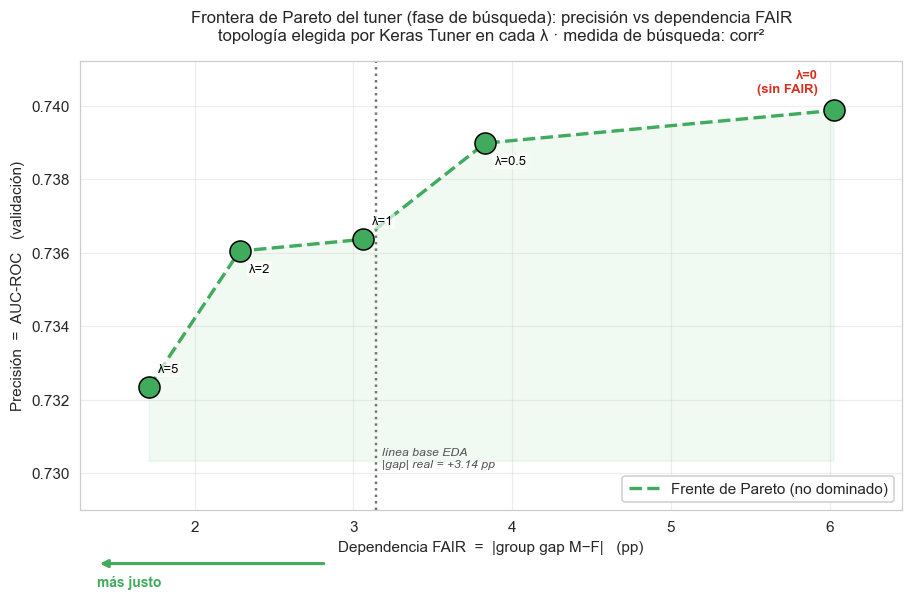

Puntos NO dominados (lambda, AUC_val, gap_pp): [(5.0, 0.7323, 1.71), (2.0, 0.736, 2.28), (1.0, 0.7364, 3.06), (0.5, 0.739, 3.83), (0.0, 0.7399, 6.02)]

Topologia backbone (mayor AUC, de λ=0.0): {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'lr': 0.007177664122743156, 'units_0': 64, 'units_1': 64}


In [7]:
# === Pareto del tuner: AUC (Y) vs Dependencia FAIR = |group gap| (X) — E2 ===
# CORREGIDO (Tanda 3): TODO en VALIDACION (mismo split, misma arquitectura-familia).
# Esta es la Pareto de la fase de BUSQUEDA (topologia variable por lambda, medida
# corr2); la frontera LIMPIA y la comparacion de las 3 medidas vienen despues.
import json as _json

if len(registros):
    puntos = [{"lambda": r["lambda"], "auc": r["auc"], "gap_pp": r["gap_pp"]} for r in registros]
    frente = tuning.pareto_front(puntos)
    set_frente = {(round(p["auc"], 6), round(p["gap_pp"], 6)) for p in frente}

    fig, ax = plt.subplots(figsize=(8.4, 5.6))
    fpts = sorted(frente, key=lambda p: abs(p["gap_pp"]))
    fx = [abs(p["gap_pp"]) for p in fpts]; fy = [p["auc"] for p in fpts]
    ax.fill_between(fx, fy, min(fy) - 0.002, color=COLOR_ACENTO, alpha=0.07, zorder=0)
    ax.plot(fx, fy, color=COLOR_ACENTO, lw=2.2, ls="--", zorder=2, label="Frente de Pareto (no dominado)")

    xs_all, ys_all, labs = [], [], []
    dominado_etiquetado = False
    for r in registros:
        en_frente = (round(r["auc"], 6), round(r["gap_pp"], 6)) in set_frente
        lbl = None
        if not en_frente and not dominado_etiquetado:
            lbl = "punto dominado"; dominado_etiquetado = True
        ax.scatter(abs(r["gap_pp"]), r["auc"], s=190 if en_frente else 70, marker="o",
                   color=COLOR_ACENTO if en_frente else COLOR_PAGA,
                   edgecolor="black", linewidth=1.0 if en_frente else 0.6,
                   zorder=4 if en_frente else 3, label=lbl)
        if r["lambda"] != 0.0:   # λ=0 tiene su propia anotacion roja -> no duplicar
            xs_all.append(abs(r["gap_pp"])); ys_all.append(r["auc"]); labs.append(f"λ={r['lambda']:g}")
    label_lambdas_sin_solape(ax, xs_all, ys_all, labs)

    r0 = next(r for r in registros if r["lambda"] == 0.0)
    ax.annotate("λ=0\n(sin FAIR)", (abs(r0["gap_pp"]), r0["auc"]),
                textcoords="offset points", xytext=(-10, 12), ha="right",
                fontsize=8.5, color=COLOR_IMPAGA, fontweight="bold")

    add_baseline_eda(ax); add_flechas_objetivo(ax)
    ax.set_xlabel("Dependencia FAIR  =  |group gap M−F|   (pp)")
    ax.set_ylabel("Precisión  =  AUC-ROC   (validación)")
    ax.set_title("Frontera de Pareto del tuner (fase de búsqueda): precisión vs dependencia FAIR\n"
                 "topología elegida por Keras Tuner en cada λ · medida de búsqueda: corr²", fontsize=11, pad=14)
    ax.legend(loc="lower right", frameon=True, framealpha=0.95)
    ax.grid(True, alpha=0.35); ax.margins(x=0.10, y=0.14)
    fig.tight_layout()
    ruta = FIG_DIR / "06_tuner__pareto_auc_vs_gap.png"
    fig.savefig(ruta, bbox_inches="tight", dpi=150)
    print("E2 (fase búsqueda) guardada:", ruta)
    plt.show()

    df_pareto = pd.DataFrame(frente)
    df_pareto.to_csv(TAB_DIR / "06_tuner__pareto_puntos.csv", index=False)
    print("Puntos NO dominados (lambda, AUC_val, gap_pp):",
          [(p["lambda"], round(p["auc"], 4), round(p["gap_pp"], 2)) for p in frente])

    # Topologia BACKBONE para el barrido limpio = la de mayor AUC (mejor capacidad)
    reg_backbone = max(registros, key=lambda r: r["auc"])
    HP_BACKBONE = _json.loads(reg_backbone["hp_values"])
    print(f"\nTopologia backbone (mayor AUC, de λ={reg_backbone['lambda']}): {HP_BACKBONE}")

## Barrido LIMPIO de las 3 medidas: topología fija + multi-semilla (aísla λ y compara D)

> **Por qué esta sección.** En el barrido del tuner cada λ usa una **topología distinta**, así que las variaciones de AUC/gap mezclan el efecto del *fairness* con el de cambiar de arquitectura — y con una sola semilla las diferencias de AUC (~0,001) caen dentro del **ruido de entrenamiento**.
>
> Aquí **fijamos la topología backbone** (la de mayor AUC del tuner) y barremos λ con las **tres medidas de dependencia de la Tarea 2** (`corr²`, `HSIC`, `MMD` de `src/fair_loss.py`), entrenando **varias semillas por punto**. Así: (1) el único factor que cambia es **(λ, medida)** → la frontera mide *fairness puro*; (2) reportamos **media ± desviación** (barras de error); (3) **comparamos las 3 medidas** y cerramos **D-2.1**.

> **Qué mira cada medida (tres lentes sobre la misma pregunta).** Todas responden a "¿depende `ŷ` del género `s`?", pero con resolución distinta:
> - **`corr²`** — correlación de Pearson al cuadrado entre `ŷ` y `s`. Solo ve la parte **lineal**; con `s` binaria eso es prácticamente el **desplazamiento de medias** entre M y F → casi una función monótona del **group gap**. Barata e interpretable, pero **ciega a la curvatura**. Vive en `[0,1]`.
> - **`HSIC`** — dependencia vía **kernels** (RBF). Capta *cualquier* forma de dependencia (lineal **y** curva) y vale 0 solo bajo independencia. Su valor bruto es minúsculo y depende del kernel, σ y `n`.
> - **`MMD²`** — *Maximum Mean Discrepancy*: compara **las distribuciones completas** del score en M vs F, no solo sus medias. Una red puede igualar las medias (corr²≈0) y aún separar las colas; MMD lo detecta.
>
> **Por qué cada medida necesita su propia rejilla de λ.** En `BCE + λ·D` el peso efectivo es `λ·D`, así que **λ debe compensar la escala de `D`**. Como `corr²∈[0,1]`, `MMD²~[0, 0.1]` y `HSIC~[0, 0.02]`, un mismo λ penaliza ~50× más fuerte con corr² que con HSIC. Por eso cada medida usa su **propia rejilla** (corr² hasta 10, MMD hasta 20, HSIC hasta 50): las tres recorren un **rango comparable de reducción del gap** y la comparación es justa. Además del *group gap* (paridad demográfica) reportamos **ΔTPR/ΔFPR** (equalized-odds) en test para el punto elegido.

In [8]:
# === Barrido limpio 3 MEDIDAS (1/3: corr2): topologia FIJA + semillas, val Y test ===
# Comparamos las 3 medidas de dependencia de la Tarea 2 (corr2 / HSIC / MMD) sobre
# la MISMA topologia backbone. Cada medida tiene su rejilla de lambda (escalas
# distintas). Se hace en 3 celdas (una por medida) para que cada bloque pese poco
# (los kernels HSIC/MMD son O(n^2) por batch). REUSO determinista: si existe el
# cache _cache_barrido_<medida>.csv se carga (resultados identicos, ya calculados);
# borra esos ficheros para forzar el recomputo completo.
SEEDS = [42, 7, 123]
LAMBDA_GRID = {
    "corr2": [0.0, 0.5, 1.0, 2.0, 5.0, 10.0],   # corr2 in [0,1]
    "mmd":   [0.0, 1.0, 2.0, 5.0, 10.0, 20.0],  # MMD^2 ~[0,0.1]
    "hsic":  [0.0, 5.0, 10.0, 20.0, 50.0],      # HSIC ~[0,0.02]
}
df_medidas = {}

def _sweep_medida(measure):
    """Barre LAMBDA_GRID[measure] sobre el backbone fijo con multi-semilla (o reusa cache)."""
    cache = TAB_DIR / f"_cache_barrido_{measure}.csv"
    if cache.exists():
        dfm = pd.read_csv(cache)
        df_medidas[measure] = dfm
        print(f"--- '{measure}': REUSADO de cache determinista ({len(dfm)} λ, "
              f"borra {cache.name} para recomputar) ---")
        return dfm
    print(f"--- Medida '{measure}'  ({tuning.fair_loss_source(measure)})  lambdas={LAMBDA_GRID[measure]} ---")
    filas = tuning.sweep_lambda_fixed(
        data, LAMBDA_GRID[measure], HP_BACKBONE, seeds=SEEDS,
        n_features=N_FEATURES, include_custom_layer=True, class_weights=CW,
        epochs=40, measure=measure, test=(X_test, y_test, s_test), verbose=0)
    dfm = pd.DataFrame(filas)
    df_medidas[measure] = dfm
    for _, r in dfm.iterrows():
        print(f"  λ={r['lambda']:<5} val AUC={r['auc_mean']:.4f}±{r['auc_std']:.4f} "
              f"gap={r['gap_mean']:+.2f}±{r['gap_std']:.2f}pp | test AUC={r['auc_test_mean']:.4f} "
              f"gap={r['gap_test_mean']:+.2f}pp | dep={r['dep_mean']:.4g}")
    return dfm

if len(registros):
    print(f"Backbone fijo: {HP_BACKBONE}")
    print(f"Semillas: {SEEDS}  (val + test, incl. ΔTPR/ΔFPR y dependencia D)\n")
    _sweep_medida("corr2")

Backbone fijo: {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'lr': 0.007177664122743156, 'units_0': 64, 'units_1': 64}
Semillas: [42, 7, 123]  (val + test, incl. ΔTPR/ΔFPR y dependencia D)

--- Medida 'corr2'  (src.fair_loss:corr2)  lambdas=[0.0, 0.5, 1.0, 2.0, 5.0, 10.0] ---


  λ=0.0   val AUC=0.7389±0.0013 gap=+5.61±0.41pp | test AUC=0.7404 gap=+5.62pp | dep=0.02111
  λ=0.5   val AUC=0.7385±0.0006 gap=+3.61±0.13pp | test AUC=0.7409 gap=+3.60pp | dep=0.009199
  λ=1.0   val AUC=0.7367±0.0004 gap=+2.81±0.24pp | test AUC=0.7394 gap=+2.83pp | dep=0.005657
  λ=2.0   val AUC=0.7353±0.0006 gap=+2.18±0.18pp | test AUC=0.7373 gap=+2.19pp | dep=0.003446
  λ=5.0   val AUC=0.7318±0.0019 gap=+1.54±0.26pp | test AUC=0.7345 gap=+1.57pp | dep=0.001802
  λ=10.0  val AUC=0.7286±0.0019 gap=+1.30±0.21pp | test AUC=0.7309 gap=+1.28pp | dep=0.001312


In [9]:
# === Barrido limpio 3 MEDIDAS (2/3: MMD) ===
if len(registros):
    _sweep_medida("mmd")

--- 'mmd': REUSADO de cache determinista (6 λ, borra _cache_barrido_mmd.csv para recomputar) ---


In [10]:
# === Barrido limpio 3 MEDIDAS (3/3: HSIC) + consolidacion ===
if len(registros):
    # Salvaguarda del cache: el cache de HSIC/MMD se calculo sobre un backbone concreto.
    # Si el tuner (re)eligio el MISMO backbone, el cache es valido; si no, avisa para recomputar.
    _json_prev = PROC_DIR.parent / "models" / "06_modelo_compromiso.json"
    if _json_prev.exists() and (TAB_DIR / "_cache_barrido_hsic.csv").exists():
        import json as _jchk
        bb_prev = _jchk.loads(_json_prev.read_text())["hp_backbone"]
        same = all(HP_BACKBONE.get(k) == bb_prev.get(k) for k in ("n_layers", "units_0", "activation", "dropout_rate"))
        if not same:
            print("AVISO: el backbone del tuner ha cambiado respecto al del cache "
                  f"(ahora units_0={HP_BACKBONE.get('units_0')}, antes {bb_prev.get('units_0')}). "
                  "Borra results/tables/_cache_barrido_*.csv y re-ejecuta para recomputar HSIC/MMD.")
        else:
            print(f"Cache HSIC/MMD consistente con el backbone actual (units_0={HP_BACKBONE.get('units_0')}).")

    _sweep_medida("hsic")
    df_limpio_all = pd.concat([df_medidas[m] for m in ["corr2", "mmd", "hsic"]], ignore_index=True)
    df_limpio_all.to_csv(TAB_DIR / "06_tuner__barrido_3medidas_seeds.csv", index=False)
    df_limpio = df_medidas["corr2"]   # compatibilidad: barrido limpio "principal"
    df_limpio.to_csv(TAB_DIR / "06_tuner__pareto_limpio_seeds.csv", index=False)
    print("\nConsolidado y guardado:", TAB_DIR / "06_tuner__barrido_3medidas_seeds.csv")

Cache HSIC/MMD consistente con el backbone actual (units_0=64).
--- 'hsic': REUSADO de cache determinista (5 λ, borra _cache_barrido_hsic.csv para recomputar) ---

Consolidado y guardado: ..\results\tables\06_tuner__barrido_3medidas_seeds.csv


## Selección de la mejor topología

Aquí se elegirá la **configuración de compromiso** (necesariamente **con dropout**) que **hereda el notebook 07** para MC-Dropout (cruce **D-3.2 ↔ D-4.1**), persistiendo sus hiperparámetros y el resumen de trials.

In [11]:
# === Seleccion del compromiso (medida, lambda) por PRESUPUESTO de AUC ===
# Criterio explicito y revisable (coherente con la Tarea 2): de entre TODAS las
# medidas y lambda>0 cuyo coste en AUC NO supere el presupuesto, el que MINIMIZA
# |group gap|. La DECISION se toma en VALIDACION (el test queda reservado, D-P.6);
# el test solo se usa para REPORTAR el punto ya elegido (tabla E5). Misma topologia
# (backbone) -> comparacion limpia. La hereda el NB07 para MC-Dropout (D-3.2<->D-4.1).
PRESUPUESTO_AUC_PP = 1.0   # se aceptan modelos que sacrifiquen <=1pp de AUC (en val)
if df_medidas:
    # AUC base (lambda=0): identica para las 3 medidas (misma red, sin penalizacion)
    auc_base_val = float(df_limpio_all[df_limpio_all["lambda"] == 0.0]["auc_mean"].mean())
    gap_base_val = float(df_limpio_all[df_limpio_all["lambda"] == 0.0]["gap_mean"].mean())

    cand = df_limpio_all[df_limpio_all["lambda"] > 0].copy()
    cand["coste_auc_pp"] = (auc_base_val - cand["auc_mean"]) * 100.0      # coste en VAL
    cand["abs_gap_val"] = cand["gap_mean"].abs()
    dentro = cand[cand["coste_auc_pp"] <= PRESUPUESTO_AUC_PP]
    pool = dentro if len(dentro) else cand          # red de seguridad si nadie entra
    fila_star = pool.loc[pool["abs_gap_val"].idxmin()]
    MEASURE_STAR = str(fila_star["measure"])
    LAMBDA_STAR  = float(fila_star["lambda"])

    print(f"Presupuesto: coste AUC (val) <= {PRESUPUESTO_AUC_PP} pp.  "
          f"Base (λ=0, val): AUC={auc_base_val:.4f}  gap={gap_base_val:+.2f}pp")
    if len(dentro) == 0:
        print("  (ninguna combinacion entra en presupuesto -> red de seguridad: menor |gap| en val)")
    print(f"\n>>> Compromiso elegido (en validacion): medida='{MEASURE_STAR}'  λ*={LAMBDA_STAR}")
    print(f"    val:  AUC={fila_star['auc_mean']:.4f}±{fila_star['auc_std']:.4f}  "
          f"gap={fila_star['gap_mean']:+.2f}±{fila_star['gap_std']:.2f}pp  (coste {fila_star['coste_auc_pp']:+.2f}pp)")
    print(f"    test: AUC={fila_star['auc_test_mean']:.4f}  gap={fila_star['gap_test_mean']:+.2f}pp  "
          f"| equalized-odds ΔTPR={fila_star['dtpr_test_mean']:+.2f}pp ΔFPR={fila_star['dfpr_test_mean']:+.2f}pp")
    assert float(HP_BACKBONE["dropout_rate"]) > 0, "El backbone DEBE tener dropout (MC-Dropout NB07)"
    print(f"    dropout={HP_BACKBONE['dropout_rate']:.1f} > 0  ->  apto para MC-Dropout del NB07 (D-4.1)")
    if fila_star["coste_auc_pp"] <= fila_star["auc_std"] * 100:
        print(f"    AVISO: coste AUC ({fila_star['coste_auc_pp']:+.2f}pp) dentro de 1σ "
              f"(±{fila_star['auc_std']*100:.2f}pp) -> sacrificio de precisión indistinguible de cero.")
    # Robustez del umbral: candidato MARGINALMENTE excluido (menor coste por encima del presupuesto)
    fuera = cand[cand["coste_auc_pp"] > PRESUPUESTO_AUC_PP].sort_values("coste_auc_pp")
    if len(fuera):
        f0 = fuera.iloc[0]
        print(f"    (robustez del umbral: '{f0['measure']}' λ={f0['lambda']:g} sería más justo "
              f"(gap {f0['gap_mean']:+.2f}pp) pero quedó fuera por solo {f0['coste_auc_pp']-PRESUPUESTO_AUC_PP:+.2f}pp de coste)")

    # === Tabla E5: base canonica (03) + base interna (λ=0) vs mejor FAIR, en TEST ===
    r0 = df_limpio_all[(df_limpio_all["lambda"] == 0.0) &
                       (df_limpio_all["measure"] == MEASURE_STAR)].iloc[0]
    red_gap = (abs(r0["gap_test_mean"]) - abs(fila_star["gap_test_mean"])) / (abs(r0["gap_test_mean"]) + 1e-9) * 100
    filas_e5 = []
    ruta_base03 = TAB_DIR / "03_base__metricas_test.csv"   # base canonica del enunciado (MLP sin FAIR)
    if ruta_base03.exists():
        b03 = pd.read_csv(ruta_base03).iloc[0]
        filas_e5.append({"modelo": "base 03 (MLP sin FAIR)", "medida": "-", "lambda": "-",
                         "AUC_test": round(float(b03["AUC_ROC"]), 4),
                         "group_gap_test_pp": round(float(b03["group_gap_pp"]), 3),
                         "dTPR_test_pp": np.nan, "dFPR_test_pp": np.nan, "mejor": ""})
    filas_e5.append({"modelo": "base tuner (λ=0, +capa custom)", "medida": "-", "lambda": 0.0,
                     "AUC_test": round(r0["auc_test_mean"], 4), "group_gap_test_pp": round(r0["gap_test_mean"], 3),
                     "dTPR_test_pp": round(r0["dtpr_test_mean"], 3), "dFPR_test_pp": round(r0["dfpr_test_mean"], 3), "mejor": ""})
    filas_e5.append({"modelo": "mejor FAIR", "medida": MEASURE_STAR, "lambda": LAMBDA_STAR,
                     "AUC_test": round(fila_star["auc_test_mean"], 4), "group_gap_test_pp": round(fila_star["gap_test_mean"], 3),
                     "dTPR_test_pp": round(fila_star["dtpr_test_mean"], 3), "dFPR_test_pp": round(fila_star["dfpr_test_mean"], 3),
                     "mejor": "  <== MEJOR (remarcar en test)"})
    tabla_e5 = pd.DataFrame(filas_e5)
    tabla_e5.to_csv(TAB_DIR / "06_tuner__base_vs_mejor_fair.csv", index=False)
    print(f"\n=== Tabla E5 (base vs mejor FAIR, test) — |gap| reducido {red_gap:.0f}% vs base λ=0 ===")
    print(tabla_e5.to_string(index=False))
    print("\nGuardada:", TAB_DIR / "06_tuner__base_vs_mejor_fair.csv")

    # Persistir trials del tuner (completos, con test e hp_values) -> tabla de apoyo
    df_full = pd.DataFrame(registros)
    df_full["es_backbone"] = df_full["lambda"] == reg_backbone["lambda"]
    df_full["estrategia"] = STRATEGY
    df_full.to_csv(TAB_DIR / "06_tuner__trials.csv", index=False)
    print("Trials guardados:", TAB_DIR / "06_tuner__trials.csv")

Presupuesto: coste AUC (val) <= 1.0 pp.  Base (λ=0, val): AUC=0.7389  gap=+5.61pp

>>> Compromiso elegido (en validacion): medida='corr2'  λ*=5.0
    val:  AUC=0.7318±0.0019  gap=+1.54±0.26pp  (coste +0.71pp)
    test: AUC=0.7345  gap=+1.57pp  | equalized-odds ΔTPR=+1.82pp ΔFPR=+3.35pp
    dropout=0.3 > 0  ->  apto para MC-Dropout del NB07 (D-4.1)
    (robustez del umbral: 'corr2' λ=10 sería más justo (gap +1.30pp) pero quedó fuera por solo +0.03pp de coste)

=== Tabla E5 (base vs mejor FAIR, test) — |gap| reducido 72% vs base λ=0 ===
                        modelo medida lambda  AUC_test  group_gap_test_pp  dTPR_test_pp  dFPR_test_pp                          mejor
        base 03 (MLP sin FAIR)      -      -    0.7437              5.358           NaN           NaN                               
base tuner (λ=0, +capa custom)      -    0.0    0.7404              5.615         8.282        11.076                               
                    mejor FAIR  corr2    5.0    0.7345      

E2 (3 medidas, group gap) guardada


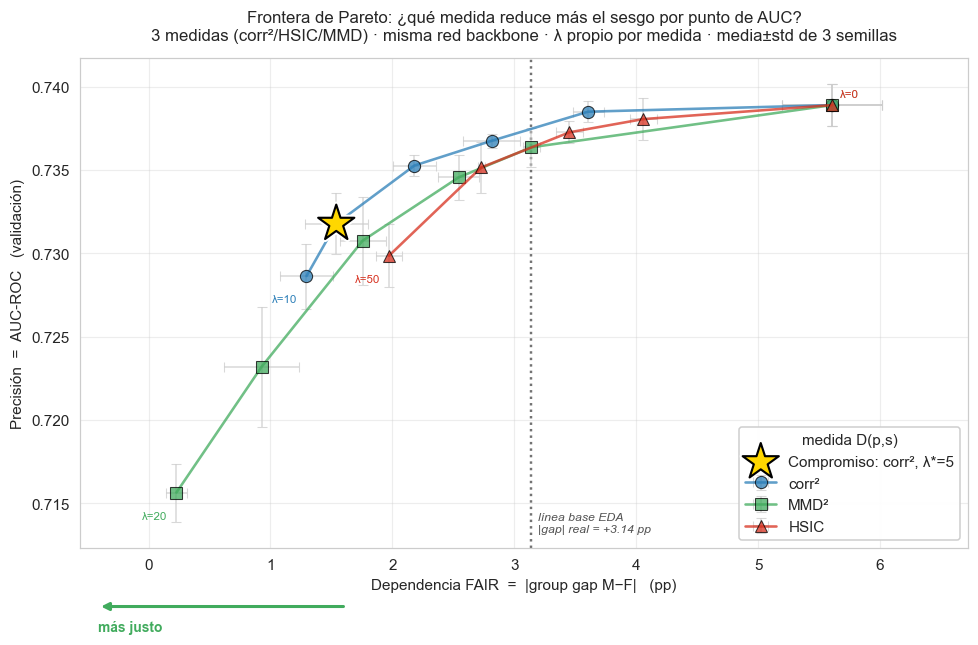

E2 (literal, dependencia D) guardada


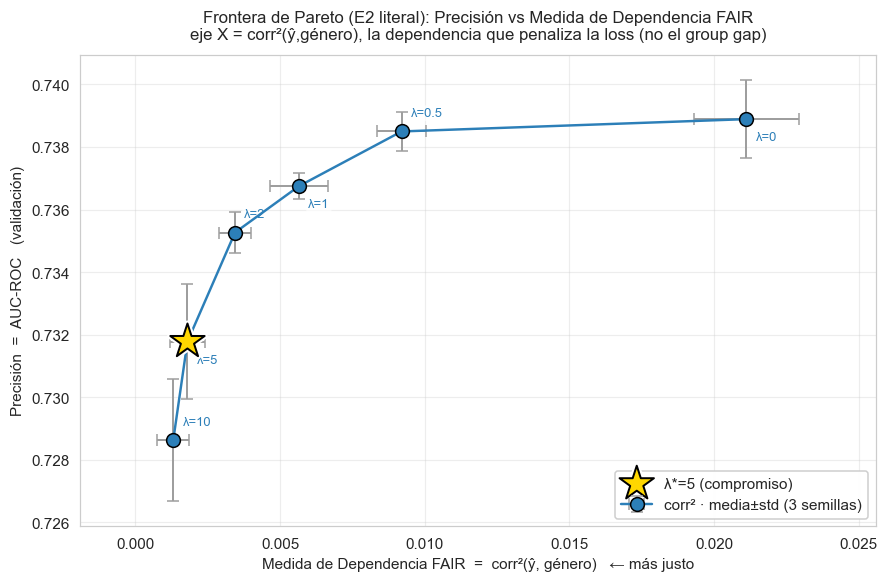

Pareto limpia (corr²) guardada


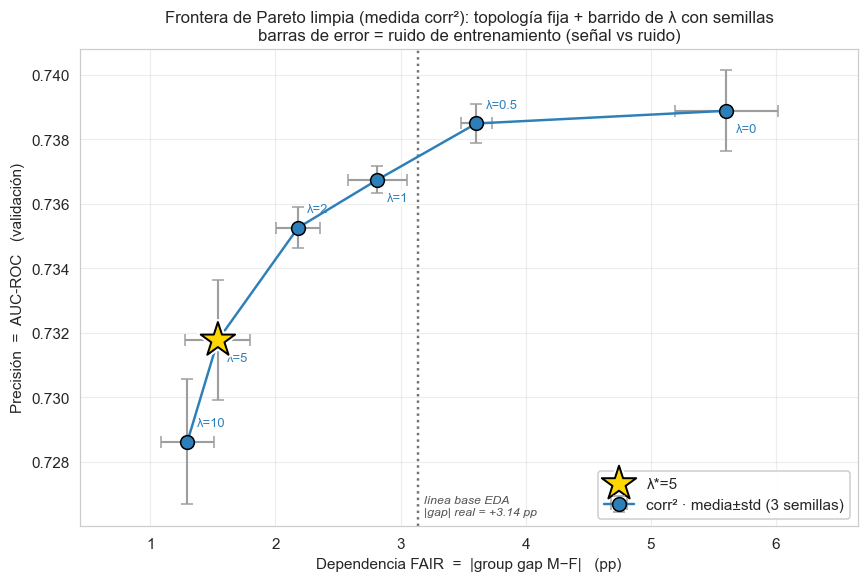

In [12]:
# === Fronteras de Pareto: 3 medidas (group gap) + E2 literal (dependencia) — E2 ===
# Tres frentes sobre la MISMA red. Se dibuja TRAS la seleccion -> la estrella marca
# el compromiso (medida*, λ*). Ademas del group gap (paridad demografica, comparable
# entre medidas) se traza la Pareto con la DEPENDENCIA D(p,s) que de verdad penaliza
# la loss (eje literal del enunciado) para la medida elegida.
import matplotlib.patheffects as pe
if df_medidas:
    # --- (A) Pareto comparada de las 3 medidas, eje X = |group gap| ---
    fig, ax = plt.subplots(figsize=(9.0, 6.0))
    estilos = {"corr2": (COLOR_PAGA, "o"), "mmd": (COLOR_ACENTO, "s"), "hsic": (COLOR_IMPAGA, "^")}
    for measure, dfm in df_medidas.items():
        c, mk = estilos[measure]
        dfm_s = dfm.sort_values("gap_mean", key=lambda x: x.abs())
        xs, ys = dfm_s["gap_mean"].abs().to_numpy(), dfm_s["auc_mean"].to_numpy()
        lams = dfm_s["lambda"].to_numpy()
        ax.errorbar(xs, ys, xerr=dfm_s["gap_std"], yerr=dfm_s["auc_std"],
                    fmt=mk + "-", color=c, ecolor="#cccccc", elinewidth=1.0, capsize=3,
                    ms=8, mec="black", mew=0.7, lw=1.7, alpha=0.75, label=NOMBRE_MEDIDA[measure], zorder=3)
        ax.annotate(f"λ={lams[-1]:g}", (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(5, 5), fontsize=7.5, color=c,
                    bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.6))
        ax.annotate(f"λ={lams[0]:g}", (xs[0], ys[0]), textcoords="offset points",
                    xytext=(-6, -12), ha="right", va="top", fontsize=7.5, color=c)
    ax.scatter([abs(fila_star["gap_mean"])], [fila_star["auc_mean"]], marker="*", s=620,
               color="gold", edgecolor="black", linewidth=1.4, zorder=7,
               path_effects=[pe.withStroke(linewidth=4, foreground="white")],
               label=f"Compromiso: {NOMBRE_MEDIDA[MEASURE_STAR]}, λ*={LAMBDA_STAR:g}")
    add_baseline_eda(ax); add_flechas_objetivo(ax)
    ax.set_xlabel("Dependencia FAIR  =  |group gap M−F|   (pp)")
    ax.set_ylabel("Precisión  =  AUC-ROC   (validación)")
    ax.set_title("Frontera de Pareto: ¿qué medida reduce más el sesgo por punto de AUC?\n"
                 "3 medidas (corr²/HSIC/MMD) · misma red backbone · λ propio por medida · media±std de 3 semillas",
                 fontsize=11, pad=12)
    ax.legend(title="medida D(p,s)", loc="lower right", frameon=True, framealpha=0.95)
    ax.grid(True, alpha=0.35); ax.margins(x=0.12, y=0.06)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "06_tuner__pareto_3medidas.png", bbox_inches="tight", dpi=150)
    print("E2 (3 medidas, group gap) guardada"); plt.show()

    # --- (B) E2 LITERAL del enunciado: Precision (Y) vs Medida de Dependencia FAIR (X) ---
    # Eje X = D(ŷ,s) penalizada por la loss (corr², medida elegida), no el group gap.
    fig, ax = plt.subplots(figsize=(8.2, 5.4))
    dca = df_medidas[MEASURE_STAR].sort_values("dep_mean")
    xs = dca["dep_mean"].to_numpy(); ys = dca["auc_mean"].to_numpy()
    cstar = estilos[MEASURE_STAR][0]
    ax.errorbar(xs, ys, xerr=dca["dep_std"], yerr=dca["auc_std"], fmt="o-", color=cstar,
                ecolor="#9e9e9e", elinewidth=1.3, capsize=4, ms=9, mec="black", lw=1.6, zorder=3,
                label=f"{NOMBRE_MEDIDA[MEASURE_STAR]} · media±std ({len(SEEDS)} semillas)")
    label_lambdas_sin_solape(ax, xs, ys, [f"λ={l:g}" for l in dca["lambda"]], color=cstar)
    ax.scatter([fila_star["dep_mean"]], [fila_star["auc_mean"]], marker="*", s=560, color="gold",
               edgecolor="black", lw=1.3, zorder=6, path_effects=[pe.withStroke(linewidth=4, foreground="white")],
               label=f"λ*={LAMBDA_STAR:g} (compromiso)")
    ax.set_xlabel(f"Medida de Dependencia FAIR  =  {NOMBRE_MEDIDA[MEASURE_STAR]}(ŷ, género)   ← más justo")
    ax.set_ylabel("Precisión  =  AUC-ROC   (validación)")
    ax.set_title("Frontera de Pareto (E2 literal): Precisión vs Medida de Dependencia FAIR\n"
                 f"eje X = {NOMBRE_MEDIDA[MEASURE_STAR]}(ŷ,género), la dependencia que penaliza la loss (no el group gap)",
                 fontsize=11, pad=10)
    ax.legend(loc="lower right", frameon=True, framealpha=0.95)
    ax.grid(True, alpha=0.35); ax.margins(x=0.12, y=0.06)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "06_tuner__pareto_dependencia.png", bbox_inches="tight", dpi=150)
    print("E2 (literal, dependencia D) guardada"); plt.show()

    # --- (C) Pareto LIMPIA corr2 (group gap) con barras de error ---
    fig, ax = plt.subplots(figsize=(8.0, 5.4))
    dcb = df_medidas["corr2"].sort_values("gap_mean", key=lambda x: x.abs())
    xs = dcb["gap_mean"].abs().to_numpy(); ys = dcb["auc_mean"].to_numpy()
    ax.errorbar(xs, ys, xerr=dcb["gap_std"], yerr=dcb["auc_std"], fmt="o-", color=COLOR_PAGA,
                ecolor="#9e9e9e", elinewidth=1.4, capsize=4, ms=9, mec="black", lw=1.6,
                zorder=3, label=f"corr² · media±std ({len(SEEDS)} semillas)")
    label_lambdas_sin_solape(ax, xs, ys, [f"λ={l:g}" for l in dcb["lambda"]], color=COLOR_PAGA)
    if MEASURE_STAR == "corr2":
        ax.scatter([abs(fila_star["gap_mean"])], [fila_star["auc_mean"]], marker="*", s=560,
                   color="gold", edgecolor="black", lw=1.3, zorder=6,
                   path_effects=[pe.withStroke(linewidth=4, foreground="white")], label=f"λ*={LAMBDA_STAR:g}")
    add_baseline_eda(ax)
    ax.set_xlabel("Dependencia FAIR  =  |group gap M−F|   (pp)")
    ax.set_ylabel("Precisión  =  AUC-ROC   (validación)")
    ax.set_title("Frontera de Pareto limpia (medida corr²): topología fija + barrido de λ con semillas\n"
                 "barras de error = ruido de entrenamiento (señal vs ruido)", fontsize=11)
    ax.legend(loc="lower right", frameon=True, framealpha=0.95)
    ax.grid(True, alpha=0.35); ax.margins(x=0.13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "06_tuner__pareto_limpia_semillas.png", bbox_inches="tight", dpi=150)
    print("Pareto limpia (corr²) guardada"); plt.show()

Figura equalized-odds guardada: ..\results\figures\06_tuner__equalized_odds_base_vs_fair.png


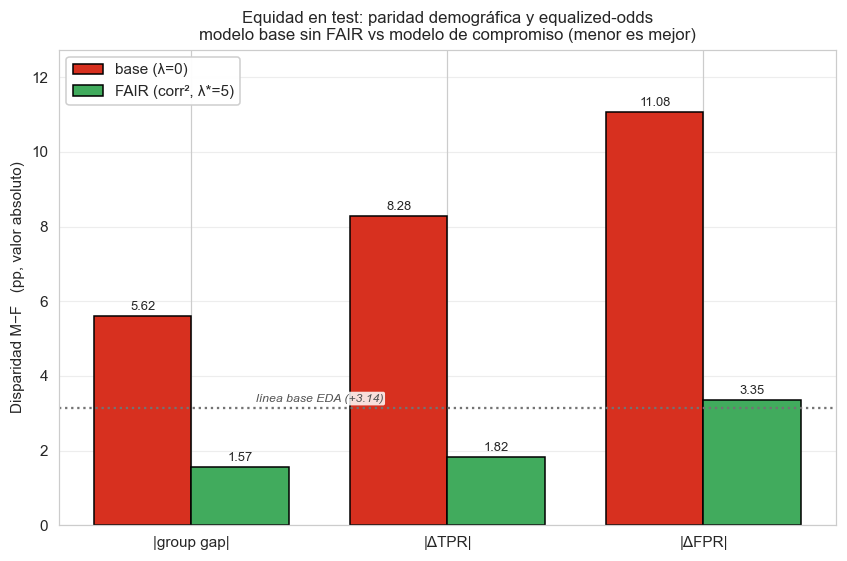

In [13]:
# === Figura: equidad en test (paridad demografica + equalized-odds), base vs FAIR ===
# La tabla E5 ya tiene group gap, ΔTPR y ΔFPR; aqui se VEN. Rojo=base (problema),
# verde=FAIR (mejora). Reducir el group gap no garantiza arreglar ΔFPR -> matiz honesto.
if df_medidas:
    metr = ["group gap", "ΔTPR", "ΔFPR"]
    base = [r0["gap_test_mean"], r0["dtpr_test_mean"], r0["dfpr_test_mean"]]
    fair = [fila_star["gap_test_mean"], fila_star["dtpr_test_mean"], fila_star["dfpr_test_mean"]]

    x = np.arange(len(metr)); w = 0.38
    fig, ax = plt.subplots(figsize=(7.8, 5.2))
    b1 = ax.bar(x - w / 2, np.abs(base), w, color=COLOR_IMPAGA, edgecolor="black", label="base (λ=0)")
    b2 = ax.bar(x + w / 2, np.abs(fair), w, color=COLOR_ACENTO, edgecolor="black",
                label=f"FAIR ({NOMBRE_MEDIDA[MEASURE_STAR]}, λ*={LAMBDA_STAR:g})")
    # rotulo del baseline EDA en el hueco entre grupos (x=0.5), no encima de las barras
    ax.axhline(GAP_BASE_EDA, color="#737373", ls=":", lw=1.5, zorder=1)
    ax.text(0.5, GAP_BASE_EDA + 0.12, f"línea base EDA (+{GAP_BASE_EDA:.2f})",
            va="bottom", ha="center", fontsize=8, color="#525252", style="italic",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
    for b in (b1, b2):
        ax.bar_label(b, fmt="%.2f", padding=2, fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels([f"|{m}|" for m in metr])
    ax.set_ylabel("Disparidad M−F   (pp, valor absoluto)")
    ax.set_ylim(0, max(np.abs(np.r_[base, fair])) * 1.15)   # headroom para el valor mas alto
    ax.set_title("Equidad en test: paridad demográfica y equalized-odds\n"
                 "modelo base sin FAIR vs modelo de compromiso (menor es mejor)", fontsize=11)
    ax.legend(frameon=True, framealpha=0.95)
    ax.grid(True, axis="y", alpha=0.35)
    fig.tight_layout()
    ruta = FIG_DIR / "06_tuner__equalized_odds_base_vs_fair.png"
    fig.savefig(ruta, bbox_inches="tight", dpi=150)
    print("Figura equalized-odds guardada:", ruta)
    plt.show()

## Cómo leer la Pareto y resultados (E2 → E5)

La frontera de la figura **E2** no es decorativa: es el menú de **puntos de operación** entre precisión y justicia. Tres claves para leerla:

1. **El codo.** Recorriendo cada curva de derecha (λ=0, máximo gap) a izquierda (λ grande, mínimo gap), al principio el gap **cae casi gratis**: bajamos dependencia FAIR sin apenas perder AUC. Pasado el **codo**, cada punto extra de justicia **cuesta AUC real**. Esa es la zona donde conviene operar.
2. **Qué medida domina.** La mejor lente es la que, **a igual AUC**, queda más a la **izquierda** (menos gap). Las barras de error (±1σ de 3 semillas) dicen si una ventaja es **real** o **ruido**: si se solapan, las medidas empatan y elegimos la más simple/barata.
3. **El precio de la justicia.** El compromiso **(medida\*, λ\*)** se elige por **presupuesto**: el modelo que **más reduce |group gap|** entre los que sacrifican **≤ 1 pp de AUC** (en validación). La tabla **E5** cuantifica ese precio en **test** y añade **ΔTPR/ΔFPR**.

### Resultados de esta ejecución

Dentro del presupuesto (coste ≤ 1 pp de AUC en validación) **gana `corr²` con `λ*=5`**. No es casualidad: con `s` binaria, `corr²` es casi una función monótona del **group gap**, así que penalizarla apunta directamente a la magnitud que queremos reducir; además es la medida más barata e interpretable.

- **El precio de la justicia es bajo.** En test, pasar del modelo base (`λ=0`) al mejor FAIR recorta el **group gap de 5,62 pp a 1,57 pp (−72 %)** sacrificando solo **0,59 pp de AUC** (0,7404 → 0,7345). Estamos a la izquierda del **codo**.
- **No es solo paridad demográfica.** La mejora se traslada a **equalized-odds**: **ΔTPR baja de 8,28 a 1,82 pp (−78 %)** y **ΔFPR de 11,08 a 3,35 pp (−70 %)**. La red no "hace trampa" igualando medias mientras desplaza los errores a un grupo.
- **Honestidad.** `corr²` no es la que más reduce el gap en absoluto: `MMD` con `λ=20` llega a ~0,18 pp (casi paridad), pero **cuesta 2,4 pp de AUC**, fuera de presupuesto; `HSIC` necesita λ muy grandes. La conclusión no es "corr² es la mejor medida en absoluto", sino que **es la mejor dado un presupuesto de 1 pp**; relajar el presupuesto movería la elección hacia `MMD`.

> **Frase para la presentación (números de test):** *"Reducimos el group gap un **72 %** (de 5,62 a 1,57 pp) pagando solo **0,59 pp de AUC**, y de paso recortamos ΔTPR y ΔFPR un 78 % y un 70 % (equalized-odds)."*

> La elección del punto de operación es **decisión de política, no de matemáticas** (`docs/teoria/02-fair-loss.md`, §4): la Pareto dice qué intercambios son *posibles*; el umbral de "justo suficiente" lo fija el grupo. Aquí lo fijamos como presupuesto explícito de AUC (`PRESUPUESTO_AUC_PP = 1.0`), revisable.

## Curva de loss del mejor trial (E4)

Aquí se graficará el `history` del **mejor trial** para evidenciar convergencia, entregable **E4** (transversal a todos los notebooks que entrenan un modelo final).

Modelo de compromiso (pesos+json) guardado para el NB07 en: ..\data\models


E4 guardada: ..\results\figures\06_tuner__curva_loss_mejor.png


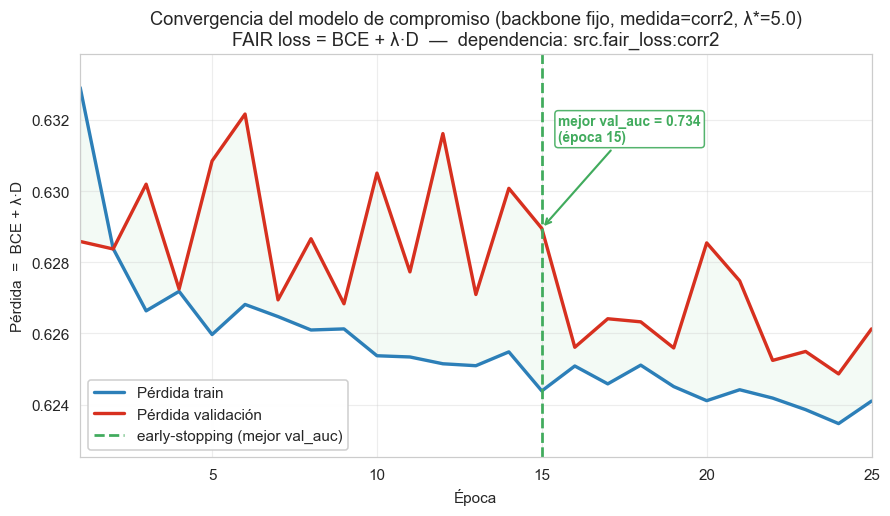

In [14]:
# === Curva de loss del modelo de compromiso real (backbone + medida* + λ*) — E4 ===
# Se reentrena UNA vez el modelo que hereda el NB07 (backbone fijo, medida* y λ*) para
# mostrar su convergencia, y se persiste para la Tarea 4 (MC-Dropout).
if df_medidas:
    import json as _json2
    keras.utils.set_random_seed(RNG)
    Xtr_np = X_train.to_numpy("float32"); ytr_pk = tuning.pack_ys(y_train, s_train)
    Xvl_np = X_val.to_numpy("float32");   yvl_pk = tuning.pack_ys(y_val, s_val)

    modelo_compromiso = tuning.build_fixed_model(HP_BACKBONE, LAMBDA_STAR,
                                                 n_features=N_FEATURES,
                                                 include_custom_layer=True, class_weights=CW,
                                                 measure=MEASURE_STAR)
    stop = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                         patience=10, restore_best_weights=True)
    hist_star = modelo_compromiso.fit(Xtr_np, ytr_pk, validation_data=(Xvl_np, yvl_pk),
                                      epochs=60, batch_size=512, callbacks=[stop], verbose=0)

    # Persistir para que el NB07 lo herede (MC-Dropout, D-4.1): pesos + json de hp.
    ruta_modelo = PROC_DIR.parent / "models"; ruta_modelo.mkdir(parents=True, exist_ok=True)
    modelo_compromiso.save_weights(ruta_modelo / "06_modelo_compromiso.weights.h5")
    (ruta_modelo / "06_modelo_compromiso.json").write_text(_json2.dumps({
        "hp_backbone": HP_BACKBONE, "lambda_star": LAMBDA_STAR, "measure_star": MEASURE_STAR,
        "class_weights": list(CW), "n_features": int(N_FEATURES),
        "include_custom_layer": True, "fair_source": tuning.fair_loss_source(MEASURE_STAR),
    }, indent=2), encoding="utf-8")
    print("Modelo de compromiso (pesos+json) guardado para el NB07 en:", ruta_modelo)

    h = hist_star.history
    epocas = np.arange(1, len(h["loss"]) + 1)
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    ax.fill_between(epocas, h["loss"], h["val_loss"], color=COLOR_ACENTO, alpha=0.06, zorder=0)
    ax.plot(epocas, h["loss"], color=COLOR_PAGA, lw=2.2, label="Pérdida train")
    ax.plot(epocas, h["val_loss"], color=COLOR_IMPAGA, lw=2.2, label="Pérdida validación")
    if "val_auc" in h:
        best = int(np.argmax(h["val_auc"]))
        ax.axvline(best + 1, color=COLOR_ACENTO, ls="--", lw=1.8, label="early-stopping (mejor val_auc)")
        ax.annotate(f"mejor val_auc = {max(h['val_auc']):.3f}\n(época {best + 1})",
                    xy=(best + 1, h["val_loss"][best]),
                    xytext=(best + 1.5, max(h["val_loss"])), ha="left", va="top",
                    color=COLOR_ACENTO, fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=COLOR_ACENTO, alpha=0.9),
                    arrowprops=dict(arrowstyle="->", color=COLOR_ACENTO, lw=1.4))
    ax.set_title(f"Convergencia del modelo de compromiso (backbone fijo, medida={MEASURE_STAR}, λ*={LAMBDA_STAR})\n"
                 f"FAIR loss = BCE + λ·D  —  dependencia: {tuning.fair_loss_source(MEASURE_STAR)}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida  =  BCE + λ·D")
    ax.set_xlim(1, len(epocas)); ax.margins(y=0.10)
    ax.legend(loc="lower left", frameon=True, framealpha=0.95)
    ax.grid(True, alpha=0.35)
    fig.tight_layout()
    ruta = FIG_DIR / "06_tuner__curva_loss_mejor.png"
    fig.savefig(ruta, bbox_inches="tight", dpi=150)
    print("E4 guardada:", ruta)
    plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_24780\2808767154.py:20: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\oscar\AppData\Local\Temp\ipykernel_24780\2808767154.py:22: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.savefig(ruta, bbox_inches="tight", dpi=150)


Panel de convergencia por λ (E4) guardado: ..\results\figures\06_tuner__curvas_loss_lambda.png


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


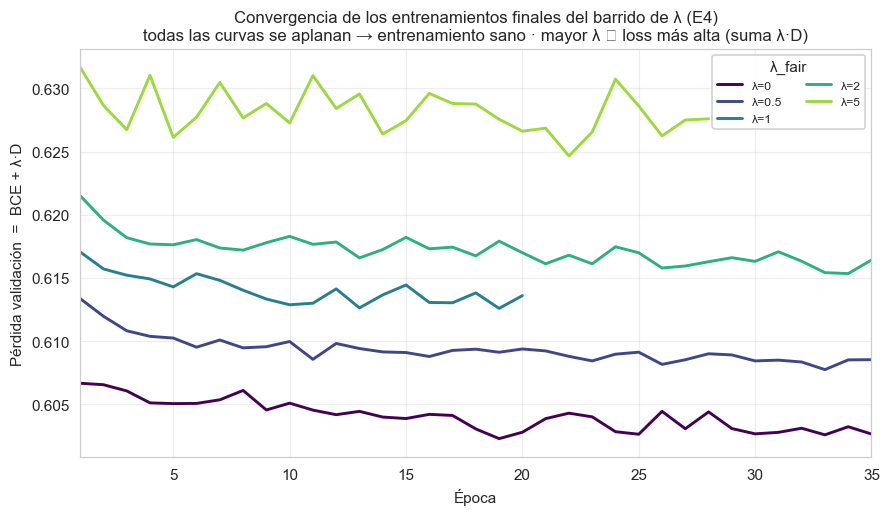

In [15]:
# === Panel de convergencia de los entrenamientos finales del barrido de λ (E4) ===
# El enunciado pide curvas de loss "para cada entrenamiento final"; ademas de la del
# modelo de compromiso, aqui se muestran las del bucle externo sobre λ (fase tuner,
# medida corr2) en un solo panel. Mayor λ -> loss mas alta (la loss SUMA λ·D), no peor modelo.
if len(registros) and histories:
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    lams_ord = sorted(histories.keys())
    colores = plt.cm.viridis(np.linspace(0, 0.85, len(lams_ord)))
    for c, lam in zip(colores, lams_ord):
        h = histories[lam].history
        if "val_loss" in h:
            ax.plot(np.arange(1, len(h["val_loss"]) + 1), h["val_loss"], color=c, lw=1.9, label=f"λ={lam:g}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida validación  =  BCE + λ·D")
    ax.set_title("Convergencia de los entrenamientos finales del barrido de λ (E4)\n"
                 "todas las curvas se aplanan → entrenamiento sano · mayor λ ⇒ loss más alta (suma λ·D)",
                 fontsize=11)
    ax.legend(title="λ_fair", loc="upper right", frameon=True, framealpha=0.95, ncol=2, fontsize=8)
    ax.grid(True, alpha=0.35); ax.margins(x=0)
    fig.tight_layout()
    ruta = FIG_DIR / "06_tuner__curvas_loss_lambda.png"
    fig.savefig(ruta, bbox_inches="tight", dpi=150)
    print("Panel de convergencia por λ (E4) guardado:", ruta)
    plt.show()

## Limitaciones y honestidad metodológica

Recogido de la auto-revisión (revisor de código + "profesor" + crítico). Lo que **sí** está controlado y lo que queda como **limitación declarada**:

**Controlado**
- **FAIR loss real de la Tarea 2.** La dependencia se toma de `src/fair_loss.py` (`DEPENDENCE_MEASURES`): se **comparan las tres medidas** `corr²`, `HSIC` y `MMD` sobre el mismo backbone (cierra **D-2.1**). `fair_loss_source(measure)` confirma `src.fair_loss:<measure>` (ya no es el fallback). La BCE ponderada por clases es **propia** (D-MB.3) e idéntica para toda medida → el término de ajuste es comparable (la escala de `D`, no).
- **Sin fuga de género:** `CODE_GENDER` nunca entra en `X` (`assert`); solo viaja en `y_true=[y,s]` y en la auditoría del gap (D-2.5).
- **Test reservado:** topología, medida y `λ*` se eligen en **validación**; el test solo se usa para reportar (E5), no guía la búsqueda (D-P.6).
- **Ruido acotado:** el barrido **limpio** fija la topología y promedia **3 semillas** con barras de error → se distingue señal de ruido. El criterio de compromiso **avisa si `ΔAUC` cae dentro de 1σ**.
- **Equidad más allá de la media:** además del *group gap* (paridad demográfica) se reportan **ΔTPR/ΔFPR** (equalized-odds) en test.
- **Eje de dependencia FAIR literal:** además del group gap, la Pareto se traza también con `D(ŷ,s)` (la medida que de verdad penaliza la loss), como pide el enunciado.
- **Reproducible:** `06_tuner__trials.csv` guarda `hp_values` completos (todas las `units_i`) y la `measure` usada.

**Limitaciones declaradas**
- **corr² ≈ monótona del group gap** bajo `s` binaria: penalizar `corr²` y reportar group gap están ligados (no idénticos). `MMD` compara distribuciones por grupo y `HSIC` capta no-linealidad genérica; la comparación de las 3 muestra **cuál reduce más gap por punto de AUC**.
- **σ del kernel sin calibrar finamente (D-2.7 Abierta).** `MMD`/`HSIC` dependen del ancho de banda σ (valores por defecto). Con `batch=512` sin `drop_remainder`, el último batch parcial hace los estimadores kernel algo más ruidosos; el promedio multi-semilla lo mitiga. La comparación es válida *a igualdad de σ y backbone*. `MMD` no está desarrollado en `docs/teoria/` (sí corr²/HSIC/CKA/MI): se usa la implementación verificada de `src/fair_loss.py`.
- **Búsqueda sobre submuestra de 60k** (retrain en train completo) y presupuesto del tuner modesto (`max_trials=12`, `max_epochs=18`): el tuner **confirma** una buena topología más que descubrir una exótica.
- **Empate de estrategias (D-3.1):** Hyperband ≈ RandomSearch dentro del ruido (val_auc ~0,7374 vs ~0,7379, Δ<0,001); se usa **RandomSearch** por ser igual de válida y más barata, no por superioridad medida.
- **Warning benigno del optimizador** (`Skipping variable loading for optimizer 'adam'…`) al recargar el mejor trial de Keras Tuner: el modelo final se **reconstruye y reentrena desde cero** (`build_fn(best_hp)` + `fit`), así que no hay fuga de estado del optimizador.
- **El backbone se busca con `corr²`:** la elección de *arquitectura* se hace con una sola medida (barata); las 3 medidas se comparan después sobre esa red fija.

## Entregables y dependencias

Este notebook produce:

- **E1** · Código de entrenamiento, búsqueda y evaluación (este notebook genera todas las figuras y tablas que siguen).
- **E2** · Frontera de Pareto **Precisión vs Dependencia FAIR** (la oficial "obtenida por Keras Tuner" es la de la fase de búsqueda):
  - `06_tuner__pareto_auc_vs_gap.png` — **E2 oficial**: Pareto del **tuner** (topología variable por λ, medida corr²).
  - `06_tuner__pareto_dependencia.png` — **E2 literal del enunciado**: eje X = `D(ŷ,género)` (la dependencia que penaliza la loss), no el group gap.
  - `06_tuner__pareto_3medidas.png` — análisis complementario: comparación de las 3 medidas (corr²/HSIC/MMD) sobre el backbone fijo, con la estrella del compromiso.
  - `06_tuner__pareto_limpia_semillas.png` — Pareto limpia (corr²) con barras de error.
  - Tablas: `06_tuner__pareto_puntos.csv`, `06_tuner__barrido_3medidas_seeds.csv` (incluye `dep_mean`), `06_tuner__pareto_limpio_seeds.csv`.
- **E5** · Tabla **base (sin FAIR) vs mejor FAIR** en test → `06_tuner__base_vs_mejor_fair.csv` (incluye el **modelo base 03 canónico**, group gap y ΔTPR/ΔFPR, con el mejor modelo remarcado), + figura `06_tuner__equalized_odds_base_vs_fair.png`.
- **Trials** del tuner → `06_tuner__trials.csv` (topología de compromiso, medida y estrategia).
- **E4** · Curvas de loss: del modelo de compromiso (`06_tuner__curva_loss_mejor.png`) y **panel con todos los λ del barrido** (`06_tuner__curvas_loss_lambda.png`).
- **Modelo para el NB07** → `data/models/06_modelo_compromiso.weights.h5` + `.json` (backbone, `λ*`, `measure*`).
- *(Presentación)* **análisis de la Pareto** (ver "Cómo leer la Pareto y resultados"): codo, qué medida domina y el precio de la justicia con números de test.

**Dependencias.** Aguas arriba: **03** (baseline de precisión), **04** (capa custom) y **05** (FAIR loss `BCE + λ·D` con las 3 medidas), que el `build_model(hp)` integra. Aguas abajo: **07** **hereda la topología + dropout + (medida, λ\*)** que aquí se fija para MC-Dropout — el **cruce D-3.2 ↔ D-4.1**.